# Sentence-level Emotion Analysis (RoBERTa GoEmotions)

This notebook computes emotion scores **per sentence** for each essay, averages them to obtain **essay-level emotion profiles**, and then compares the **average emotion differences** between AI-generated and humanized essays.


In [2]:
!pip install pandas
!pip install transformers
!pip install torch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.9/9.9 MB 32.1 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 20.8 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [pandas]2m1/2 [pandas]
  Using cached tokenizers-0.22.2-cp39-abi3-macosx_11_0_arm64.whl.metadata (7.3 kB)
  Using cached typer-0.24.1-py3-none-any.whl.metadata (16 kB)
  Using cached safetensors-0.7.0-cp38-abi3-macosx_11_0_arm64.whl.metadata (4.1 kB)
  Using cached tqdm-4.67.3-py3-none-any.whl.metadata (57 kB)
  Using cached filelock-3.25.2-py3-none-any.whl.metadata (2.0 kB)
  Using cached httpx-0.28.1-py3-none-any.whl.metadata (7.1 kB)
  Using cached anyio-4.13.0-py3-none-any.whl.metadata (4.5 kB)
  Using cached certifi-2026.2.25-py3-none-any.whl.metadata (2.5 kB)
  Using cached httpcore-1.0.9-py3-none-any.whl.metadata (21 kB)
  Using cached idna-3.11-py3-none-any.whl.metadata (8.4 kB)
  Using cached h11-0.16.0-py3-none-any.whl.metadata (8.3 kB)
  Using cached click-8.

In [3]:
import pandas as pd
import numpy as np
from transformers import pipeline
from tqdm import tqdm
import re


# Display all columns when inspecting dataframes
pd.set_option('display.max_columns', None)

print("Loading RoBERTa GoEmotions model (SamLowe/roberta-base-go_emotions)...")
emotion_classifier = pipeline(
    "text-classification",
    model="SamLowe/roberta-base-go_emotions",
    top_k=None  # get scores for all emotions
)

print("Loading dataset...")
df = pd.read_csv("../datasets.csv")
print(df.shape)
print(df.columns.tolist())

/opt/miniconda3/envs/sbert_new/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Loading RoBERTa GoEmotions model (SamLowe/roberta-base-go_emotions)...


Loading weights: 100%|██████████| 201/201 [00:00<00:00, 8494.60it/s]
RobertaForSequenceClassification LOAD REPORT from: SamLowe/roberta-base-go_emotions
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading dataset...
(180, 6)
['topic', 'length', 'AI_model', 'humanizer', 'AI_essay', 'humanized_essay']


In [4]:
def split_into_sentences(text: str):
    """Simple sentence splitter using punctuation. Adjust if you need more accuracy."""
    if pd.isna(text) or text.strip() == "":
        return []
    # Normalize whitespace
    text = re.sub(r"\s+", " ", text.strip())
    # Split on ., !, ? followed by space or end of string
    sentences = re.split(r"(?<=[.!?])\s+", text)
    # Drop very short fragments
    sentences = [s.strip() for s in sentences if len(s.strip()) > 0]
    return sentences


def get_emotion_scores(text: str, max_chars: int = 2000):
    """Run the GoEmotions classifier on a single text and return {emotion: score} dict."""
    if pd.isna(text) or text.strip() == "":
        return None

    # Truncate long text for safety
    if len(text) > max_chars:
        text = text[:max_chars]

    try:
        results = emotion_classifier(text)
        # results is a list with one element; that element is a list of {label, score}
        emotion_dict = {item["label"]: item["score"] for item in results[0]}
        return emotion_dict
    except Exception as e:
        print(f"Error processing text: {e}")
        return None


def get_sentence_level_emotions(text: str):
    """Return per-sentence emotion scores and essay-level averages.

    Returns
    -------
    sentences: list[str]
    sentence_scores: list[dict]  # one dict per sentence
    essay_avg: dict              # mean score per emotion across sentences
    """
    sentences = split_into_sentences(text)
    sentence_scores = []

    for sent in sentences:
        scores = get_emotion_scores(sent)
        if scores is not None:
            sentence_scores.append(scores)

    if not sentence_scores:
        return sentences, [], None

    # Convert list of dicts to DataFrame and average across sentences
    sent_df = pd.DataFrame(sentence_scores)
    essay_avg = sent_df.mean(axis=0).to_dict()
    return sentences, sentence_scores, essay_avg

In [5]:
# Compute sentence-level emotions for AI and humanized essays

ai_sentences = []              # list[list[str]] per essay
ai_sentence_scores = []        # list[list[dict]] per essay
ai_essay_avg_emotions = []     # list[dict] per essay

human_sentences = []
human_sentence_scores = []
human_essay_avg_emotions = []

print("Processing AI essays sentence by sentence...")
for text in tqdm(df["AI_essay"].values, desc="AI essays"):
    sents, s_scores, avg_scores = get_sentence_level_emotions(text)
    ai_sentences.append(sents)
    ai_sentence_scores.append(s_scores)
    ai_essay_avg_emotions.append(avg_scores)

print("Processing humanized essays sentence by sentence...")
for text in tqdm(df["humanized_essay"].values, desc="Humanized essays"):
    sents, s_scores, avg_scores = get_sentence_level_emotions(text)
    human_sentences.append(sents)
    human_sentence_scores.append(s_scores)
    human_essay_avg_emotions.append(avg_scores)

# Attach to dataframe for reference / further analysis
df["AI_sentences"] = ai_sentences
df["AI_sentence_emotions"] = ai_sentence_scores
df["AI_essay_avg_emotions"] = ai_essay_avg_emotions

df["human_sentences"] = human_sentences
df["human_sentence_emotions"] = human_sentence_scores
df["human_essay_avg_emotions"] = human_essay_avg_emotions

# Optionally save an intermediate file with sentence-level info
df.to_csv("../datasets_sentence_level_emotions.csv", index=False)
print("Saved ../datasets_sentence_level_emotions.csv")

Processing AI essays sentence by sentence...


AI essays: 100%|██████████| 180/180 [02:02<00:00,  1.47it/s]


Processing humanized essays sentence by sentence...


Humanized essays: 100%|██████████| 180/180 [02:12<00:00,  1.36it/s]


Saved ../datasets_sentence_level_emotions.csv


In [6]:
# Build a flat table of essay-level averaged emotion scores (from sentence-level outputs)

# Get full list of emotions from the first non-empty essay
all_emotions = None
for avg in ai_essay_avg_emotions:
    if isinstance(avg, dict) and avg:
        all_emotions = list(avg.keys())
        break

if all_emotions is None:
    raise ValueError("No emotion scores were computed; check the pipeline and dataset.")

# Create columns for each emotion based on sentence-level averages
for emotion in all_emotions:
    df[f"AI_sentavg_{emotion}"] = [
        (avg.get(emotion) if isinstance(avg, dict) and avg is not None else np.nan)
        for avg in ai_essay_avg_emotions
    ]
    df[f"human_sentavg_{emotion}"] = [
        (avg.get(emotion) if isinstance(avg, dict) and avg is not None else np.nan)
        for avg in human_essay_avg_emotions
    ]

# Compute overall mean (across essays) of these sentence-averaged scores
ai_avg_emotions = {
    emotion: df[f"AI_sentavg_{emotion}"].mean() for emotion in all_emotions
}
human_avg_emotions = {
    emotion: df[f"human_sentavg_{emotion}"].mean() for emotion in all_emotions
}

comparison = pd.DataFrame({
    "Emotion": all_emotions,
    "AI_SentenceAvg": [ai_avg_emotions[e] for e in all_emotions],
    "Humanized_SentenceAvg": [human_avg_emotions[e] for e in all_emotions],
})
comparison["Difference_Humanized_minus_AI"] = (
    comparison["Humanized_SentenceAvg"] - comparison["AI_SentenceAvg"]
)
comparison = comparison.sort_values("Difference_Humanized_minus_AI", ascending=False)

comparison.head()

,Emotion,AI_SentenceAvg,Humanized_SentenceAvg,Difference_Humanized_minus_AI
2,neutral,0.464567,0.489778,0.025211
0,disappointment,0.032907,0.035396,0.002489
15,love,0.008125,0.010446,0.002321
3,annoyance,0.024988,0.027081,0.002093
11,caring,0.021290,0.022854,0.001565


In [7]:
# Inspect the top and bottom emotions by sentence-level averaged difference

print("Top 10 emotions where humanized essays have higher average (sentence-level) scores:")
print(comparison.head(10).to_string(index=False))

print("\nTop 10 emotions where AI essays have higher average (sentence-level) scores:")
print(comparison.tail(10).sort_values("Difference_Humanized_minus_AI").to_string(index=False))

# Save results for later analysis/comparison with the previous whole-essay method
comparison.to_csv("../emotion_comparison_sentence_level.csv", index=False)
print("\nSaved ../emotion_comparison_sentence_level.csv")

Top 10 emotions where humanized essays have higher average (sentence-level) scores:
       Emotion  AI_SentenceAvg  Humanized_SentenceAvg  Difference_Humanized_minus_AI
       neutral        0.464567               0.489778                       0.025211
disappointment        0.032907               0.035396                       0.002489
          love        0.008125               0.010446                       0.002321
     annoyance        0.024988               0.027081                       0.002093
        caring        0.021290               0.022854                       0.001565
     amusement        0.015874               0.017296                       0.001422
           joy        0.041877               0.043110                       0.001234
     gratitude        0.003037               0.004262                       0.001224
   disapproval        0.028969               0.030092                       0.001123
        desire        0.006461               0.007353             

In [8]:
!pip install seaborn
!pip install matplotlib

  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
  Using cached contourpy-1.3.3-cp311-cp311-macosx_11_0_arm64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.1/8.1 MB 11.2 MB/s  0:00:00 eta 0:00:01
Using cached contourpy-1.3.3-cp311-cp311-macosx_11_0_arm64.whl (270 kB)
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 16.0 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.7/4.7 MB 13.6 MB/s  0:00:00 eta 0:00:01
Using cached pyparsing-3.3.2-py3-none-any.whl (122 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8/8 [seaborn]m7/8 [seaborn]ib]


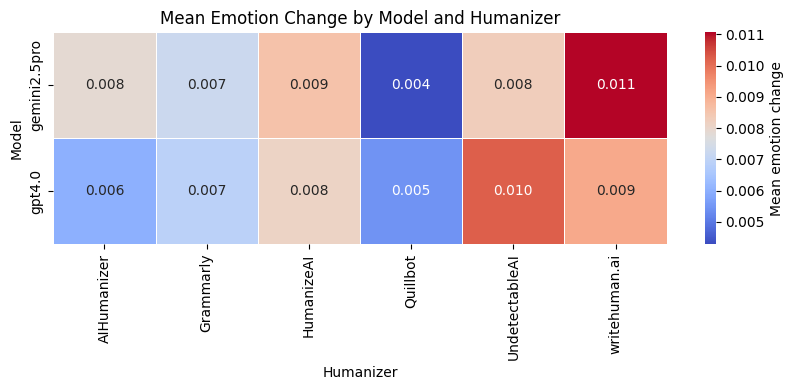

In [16]:
# Plot emotion change as a heatmap: y = AI_model, x = humanizer
import seaborn as sns
import matplotlib.pyplot as plt

model_col = "AI_model"
humanizer_col = "humanizer"

if model_col not in df.columns or humanizer_col not in df.columns:
    raise KeyError(f"Missing required columns. Available columns: {df.columns.tolist()}")

emotion_names = [c.replace("AI_sentavg_", "") for c in df.columns if c.startswith("AI_sentavg_")]
if not emotion_names:
    raise ValueError("No sentence-averaged emotion columns found.")

def row_emotion_change(row):
    diffs = []
    for emotion in emotion_names:
        ai_val = row.get(f"AI_sentavg_{emotion}", np.nan)
        human_val = row.get(f"human_sentavg_{emotion}", np.nan)
        if pd.notna(ai_val) and pd.notna(human_val):
            diffs.append(abs(ai_val - human_val))
    return np.nan if not diffs else float(np.mean(diffs))

df["emotion_change"] = df.apply(row_emotion_change, axis=1)

heatmap_df = (
    df.groupby([model_col, humanizer_col], dropna=False)["emotion_change"]
      .mean()
      .reset_index()
)

heatmap_pivot = heatmap_df.pivot(index=model_col, columns=humanizer_col, values="emotion_change")

plt.figure(figsize=(max(8, 1.4 * heatmap_pivot.shape[1]), max(4, 0.8 * heatmap_pivot.shape[0])))
sns.heatmap(
    heatmap_pivot,
    annot=True,
    fmt=".3f",
    cmap="coolwarm",
    linewidths=0.5,
    cbar_kws={"label": "Mean emotion change"}
)
plt.title("Mean Emotion Change by Model and Humanizer")
plt.xlabel("Humanizer")
plt.ylabel("Model")
plt.tight_layout()
plt.show()

heatmap_df.to_csv("../emotion_change_by_model_humanizer.csv", index=False)

In [11]:
# Build a flat table of essay-level averaged emotion scores (from sentence-level outputs)

# Get full list of emotions from the first non-empty essay
all_emotions = None
for avg in ai_essay_avg_emotions:
    if isinstance(avg, dict) and avg:
        all_emotions = list(avg.keys())
        break

if all_emotions is None:
    raise ValueError("No emotion scores were computed; check the pipeline and dataset.")

# Create columns for each emotion based on sentence-level averages
for emotion in all_emotions:
    df[f"AI_sentavg_{emotion}"] = [
        (avg.get(emotion) if isinstance(avg, dict) and avg is not None else np.nan)
        for avg in ai_essay_avg_emotions
    ]
    df[f"human_sentavg_{emotion}"] = [
        (avg.get(emotion) if isinstance(avg, dict) and avg is not None else np.nan)
        for avg in human_essay_avg_emotions
    ]

# Compute overall mean (across essays) of these sentence-averaged scores
ai_avg_emotions = {
    emotion: df[f"AI_sentavg_{emotion}"].mean() for emotion in all_emotions
}
human_avg_emotions = {
    emotion: df[f"human_sentavg_{emotion}"].mean() for emotion in all_emotions
}

comparison = pd.DataFrame({
    "Emotion": all_emotions,
    "AI_SentenceAvg": [ai_avg_emotions[e] for e in all_emotions],
    "Humanized_SentenceAvg": [human_avg_emotions[e] for e in all_emotions],
})
comparison["Difference_Humanized_minus_AI"] = (
    comparison["Humanized_SentenceAvg"] - comparison["AI_SentenceAvg"]
)
comparison = comparison.sort_values("Difference_Humanized_minus_AI", ascending=False)

comparison.head()

,Emotion,AI_SentenceAvg,Humanized_SentenceAvg,Difference_Humanized_minus_AI
2,neutral,0.464567,0.489778,0.025211
0,disappointment,0.032907,0.035396,0.002489
15,love,0.008125,0.010446,0.002321
3,annoyance,0.024988,0.027081,0.002093
11,caring,0.021290,0.022854,0.001565


In [12]:
# Inspect the top and bottom emotions by sentence-level averaged difference

print("Top 10 emotions where humanized essays have higher average (sentence-level) scores:")
print(comparison.head(10).to_string(index=False))

print("\nTop 10 emotions where AI essays have higher average (sentence-level) scores:")
print(comparison.tail(10).sort_values("Difference_Humanized_minus_AI").to_string(index=False))

# Save results for later analysis/comparison with the previous whole-essay method
comparison.to_csv("../emotion_comparison_sentence_level.csv", index=False)
print("\nSaved ../emotion_comparison_sentence_level.csv")

Top 10 emotions where humanized essays have higher average (sentence-level) scores:
       Emotion  AI_SentenceAvg  Humanized_SentenceAvg  Difference_Humanized_minus_AI
       neutral        0.464567               0.489778                       0.025211
disappointment        0.032907               0.035396                       0.002489
          love        0.008125               0.010446                       0.002321
     annoyance        0.024988               0.027081                       0.002093
        caring        0.021290               0.022854                       0.001565
     amusement        0.015874               0.017296                       0.001422
           joy        0.041877               0.043110                       0.001234
     gratitude        0.003037               0.004262                       0.001224
   disapproval        0.028969               0.030092                       0.001123
        desire        0.006461               0.007353             

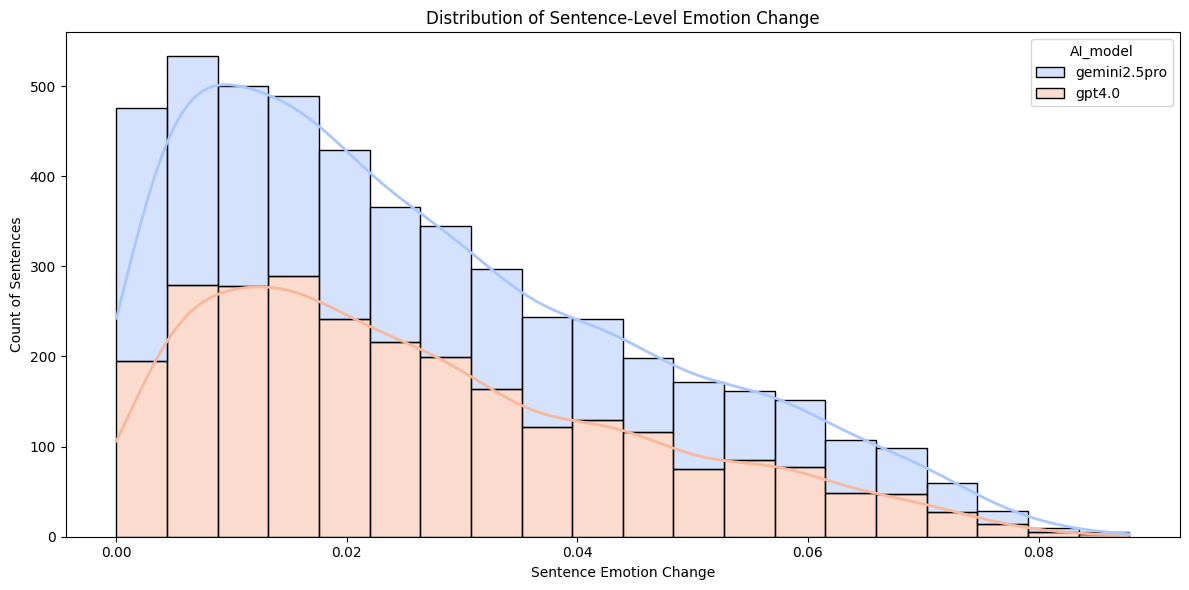

In [19]:
# Sentence-level emotion change distribution: x = change level, y = sentence count

def sentence_change_from_dicts(ai_scores, human_scores):
    changes = []
    n = min(len(ai_scores), len(human_scores))
    for i in range(n):
        ai_d = ai_scores[i]
        human_d = human_scores[i]
        common = set(ai_d.keys()) & set(human_d.keys())
        if common:
            changes.append(float(np.mean([abs(ai_d[e] - human_d[e]) for e in common])))
    return changes

sentence_rows = []
for _, row in df.iterrows():
    ai_scores = row.get("AI_sentence_emotions", []) or []
    human_scores = row.get("human_sentence_emotions", []) or []
    changes = sentence_change_from_dicts(ai_scores, human_scores)

    for change in changes:
        sentence_rows.append({
            "AI_model": row.get("AI_model", np.nan),
            "humanizer": row.get("humanizer", np.nan),
            "sentence_change": change
        })

sentence_change_df = pd.DataFrame(sentence_rows)

plt.figure(figsize=(12, 6))
sns.histplot(
    data=sentence_change_df,
    x="sentence_change",
    hue="AI_model",
    multiple="stack",
    bins=20,
    palette="coolwarm",
    kde=True,
    line_kws={"linewidth": 2}
)
plt.title("Distribution of Sentence-Level Emotion Change")
plt.xlabel("Sentence Emotion Change")
plt.ylabel("Count of Sentences")
plt.tight_layout()
plt.show()

sentence_change_df.to_csv("../sentence_level_emotion_change_distribution.csv", index=False)

In [20]:
import ast
import pandas as pd

# Helper to count sentences safely (works for list or stringified list)
def safe_len_sent(x):
    if isinstance(x, list):
        return len(x)
    if isinstance(x, str):
        x = x.strip()
        if x.startswith("[") and x.endswith("]"):
            try:
                parsed = ast.literal_eval(x)
                if isinstance(parsed, list):
                    return len(parsed)
            except Exception:
                pass
    return 0

# Per-row counts
df["AI_sentence_count"] = df["AI_sentences"].apply(safe_len_sent)
df["human_sentence_count"] = df["human_sentences"].apply(safe_len_sent)

# Keep GPT + Gemini only (adjust names if needed)
target_models = ["gpt4.0", "gemini2.5pro"]
summary = (
    df[df["AI_model"].isin(target_models)]
    .groupby("AI_model", as_index=False)[["AI_sentence_count", "human_sentence_count"]]
    .sum()
    .rename(columns={
        "AI_sentence_count": "AI_text_total_sentences",
        "human_sentence_count": "Humanized_text_total_sentences"
    })
)

print(summary.to_string(index=False))

    AI_model  AI_text_total_sentences  Humanized_text_total_sentences
gemini2.5pro                     2358                            2451
      gpt4.0                     2640                            2722


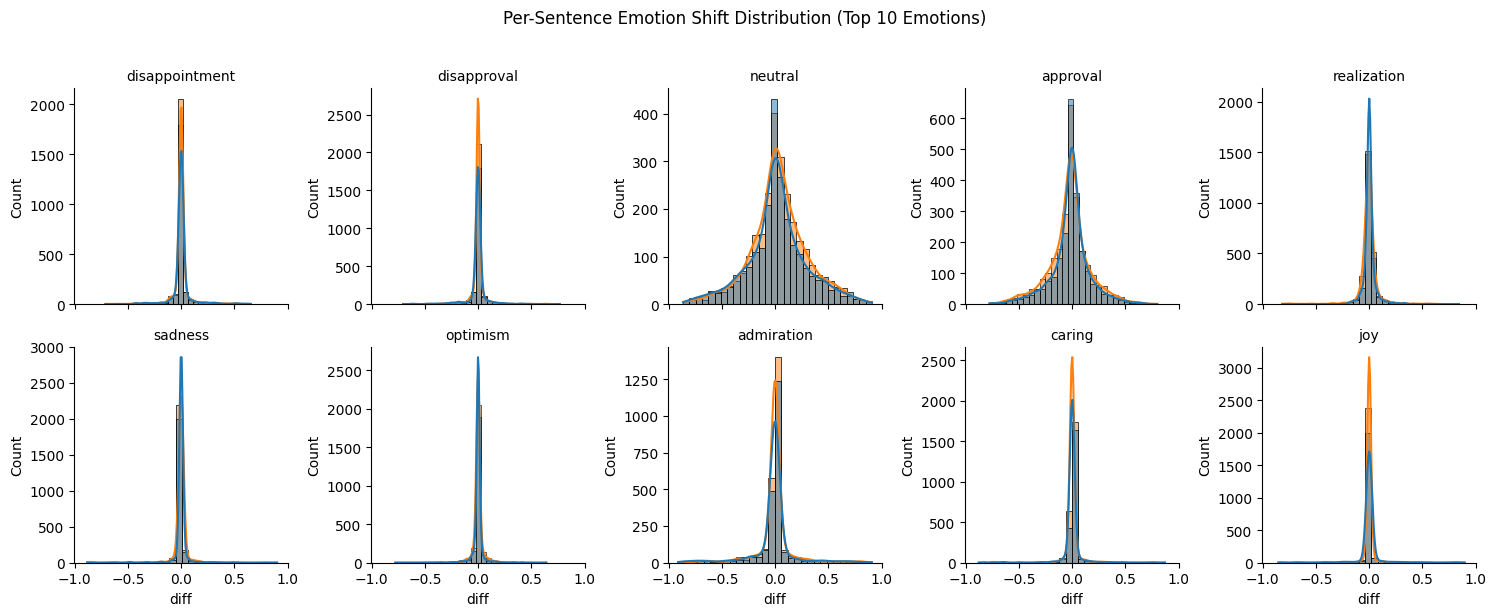

In [21]:
# Flatten to per-sentence, per-emotion rows
flat_rows = []
for _, row in df.iterrows():
    ai_scores = row.get("AI_sentence_emotions", []) or []
    human_scores = row.get("human_sentence_emotions", []) or []
    n = min(len(ai_scores), len(human_scores))
    for i in range(n):
        for emotion in ai_scores[i]:
            if emotion in human_scores[i]:
                flat_rows.append({
                    "AI_model": row.get("AI_model"),
                    "emotion": emotion,
                    "diff": human_scores[i][emotion] - ai_scores[i][emotion]  # signed!
                })

flat_df = pd.DataFrame(flat_rows)

# Focus on top N most-changed emotions only
top_emotions = flat_df.groupby("emotion")["diff"].apply(lambda x: abs(x).mean()).nlargest(10).index
plot_data = flat_df[flat_df["emotion"].isin(top_emotions)]

g = sns.FacetGrid(plot_data, col="emotion", col_wrap=5, height=3, sharey=False)
g.map_dataframe(sns.histplot, x="diff", hue="AI_model", bins=30, kde=True)
g.set_titles("{col_name}")
plt.suptitle("Per-Sentence Emotion Shift Distribution (Top 10 Emotions)", y=1.02)
plt.tight_layout()
plt.show()

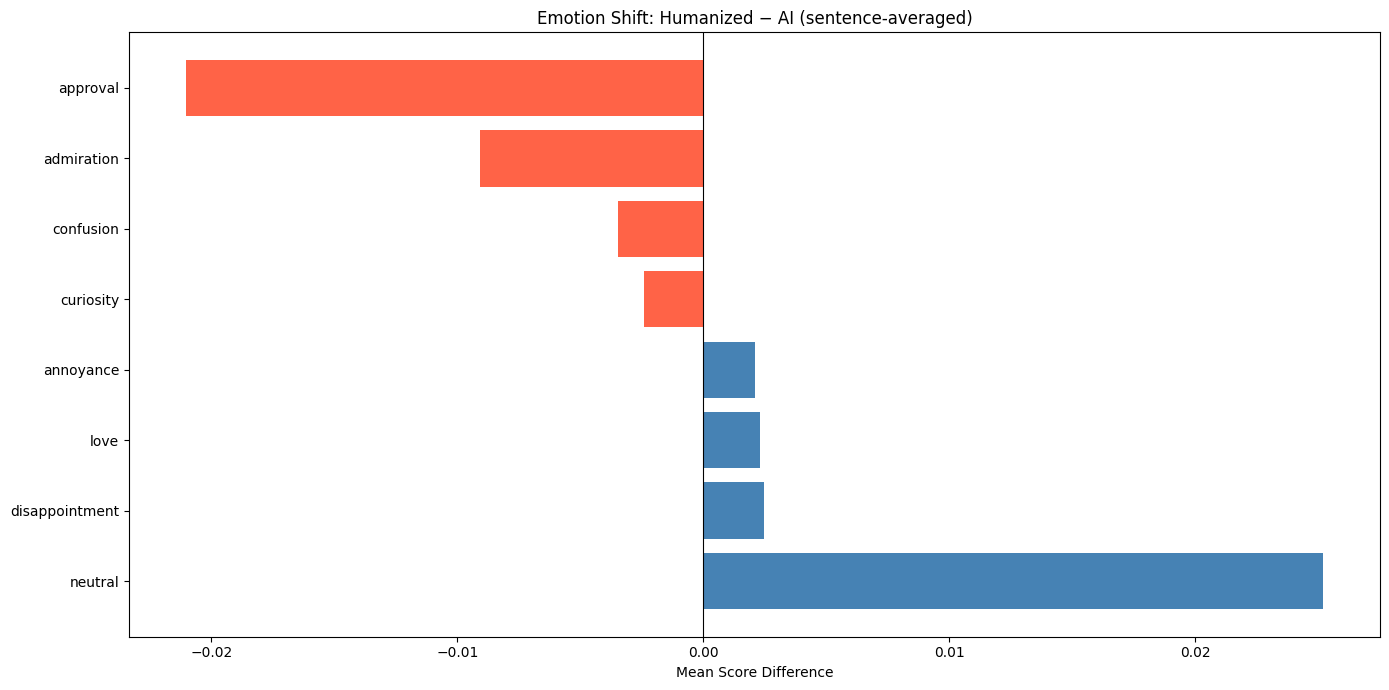

In [22]:
# Melt comparison into long form for plotting
plot_df = comparison.copy()
plot_df = plot_df[abs(plot_df["Difference_Humanized_minus_AI"]) > 0.002]  # filter noise

plt.figure(figsize=(14, 7))
colors = plot_df["Difference_Humanized_minus_AI"].apply(lambda x: "steelblue" if x > 0 else "tomato")
plt.barh(plot_df["Emotion"], plot_df["Difference_Humanized_minus_AI"], color=colors)
plt.axvline(0, color="black", linewidth=0.8)
plt.title("Emotion Shift: Humanized − AI (sentence-averaged)")
plt.xlabel("Mean Score Difference")
plt.tight_layout()
plt.show()

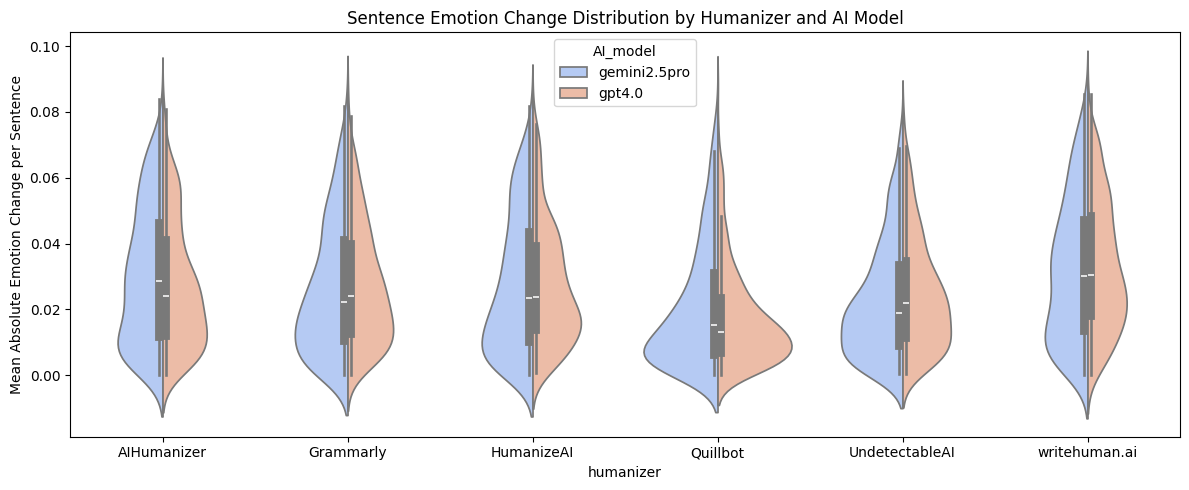

In [23]:
plt.figure(figsize=(12, 5))
sns.violinplot(
    data=sentence_change_df,
    x="humanizer", y="sentence_change",
    hue="AI_model", split=True, palette="coolwarm"
)
plt.title("Sentence Emotion Change Distribution by Humanizer and AI Model")
plt.ylabel("Mean Absolute Emotion Change per Sentence")
plt.tight_layout()
plt.show()

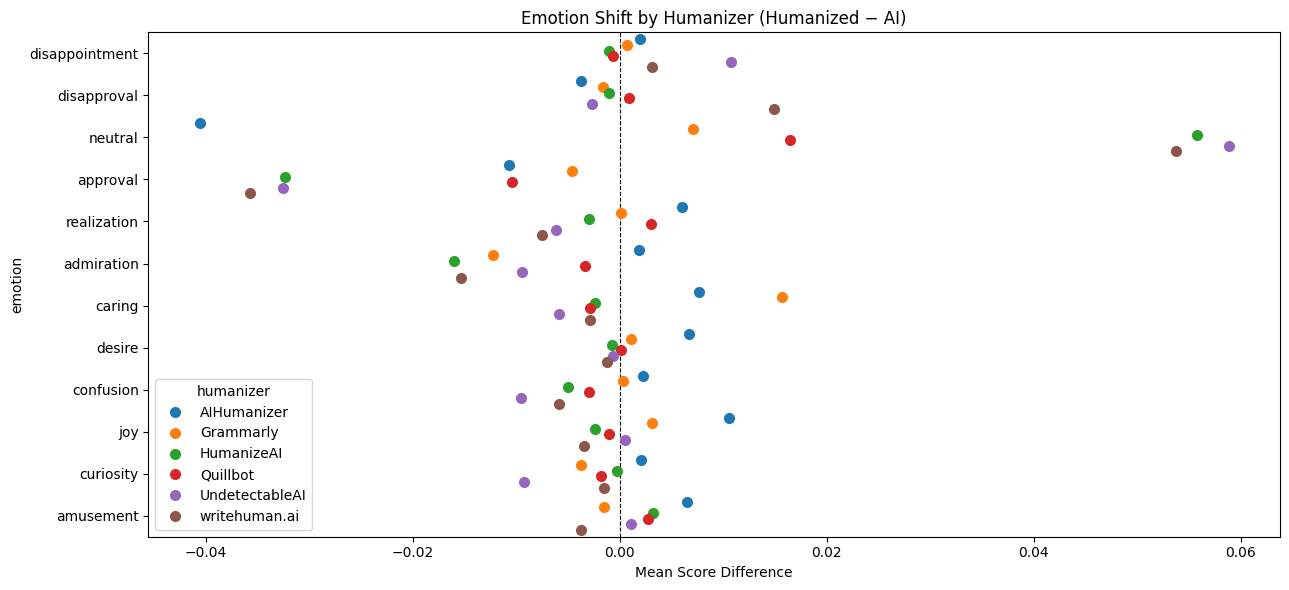

In [24]:
# Mean per humanizer per emotion
humanizer_emotion = []
for humanizer in df["humanizer"].dropna().unique():
    sub = df[df["humanizer"] == humanizer]
    for e in all_emotions:
        diff = sub[f"human_sentavg_{e}"].mean() - sub[f"AI_sentavg_{e}"].mean()
        humanizer_emotion.append({"humanizer": humanizer, "emotion": e, "diff": diff})

he_df = pd.DataFrame(humanizer_emotion)

# Keep only emotions with notable shifts
sig_emotions = he_df.groupby("emotion")["diff"].apply(lambda x: abs(x).max()).nlargest(12).index
plot_df = he_df[he_df["emotion"].isin(sig_emotions)]

plt.figure(figsize=(13, 6))
sns.stripplot(data=plot_df, x="diff", y="emotion", hue="humanizer",
              dodge=True, size=8, palette="tab10", jitter=False)
plt.axvline(0, color="black", lw=0.8, linestyle="--")
plt.title("Emotion Shift by Humanizer (Humanized − AI)")
plt.xlabel("Mean Score Difference")
plt.tight_layout()
plt.show()

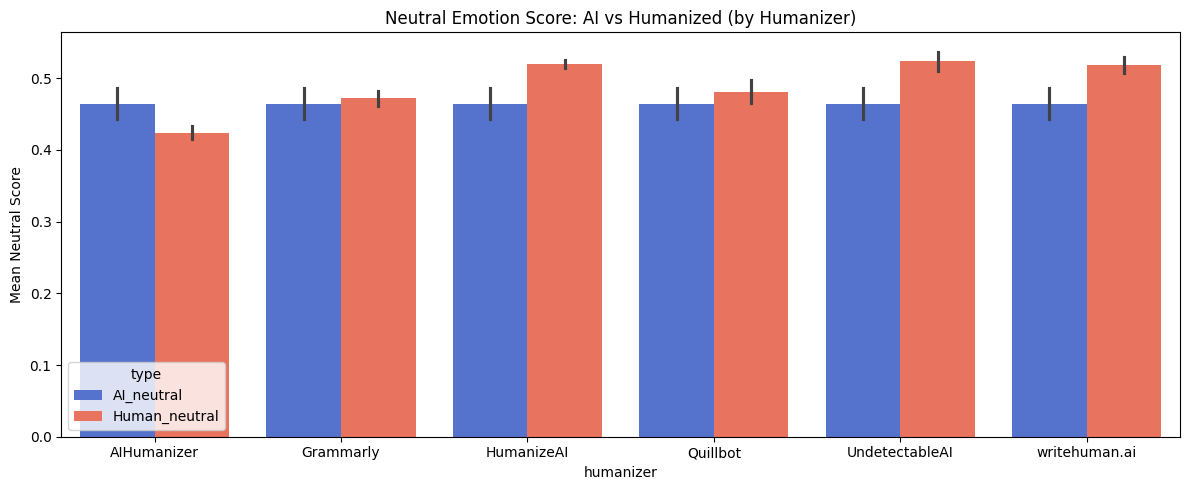

In [25]:
neu_df = df.groupby(["AI_model", "humanizer"]).agg(
    AI_neutral=("AI_sentavg_neutral", "mean"),
    Human_neutral=("human_sentavg_neutral", "mean")
).reset_index()
neu_df["reduction"] = neu_df["AI_neutral"] - neu_df["Human_neutral"]

neu_melt = neu_df.melt(id_vars=["AI_model", "humanizer"],
                        value_vars=["AI_neutral", "Human_neutral"],
                        var_name="type", value_name="neutral_score")

plt.figure(figsize=(12, 5))
sns.barplot(data=neu_melt, x="humanizer", y="neutral_score",
            hue="type", palette=["royalblue", "tomato"])
plt.title("Neutral Emotion Score: AI vs Humanized (by Humanizer)")
plt.ylabel("Mean Neutral Score")
plt.tight_layout()
plt.show()

In [27]:
!pip install scipy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 20.3/20.3 MB 20.0 MB/s  0:00:01 eta 0:00:01


In [28]:
# Instead of just neutral score, compute emotional diversity (entropy)
from scipy.stats import entropy

def emotion_entropy(avg_dict):
    if not avg_dict or not isinstance(avg_dict, dict):
        return np.nan
    vals = np.array(list(avg_dict.values()))
    vals = vals / vals.sum()  # normalize to prob distribution
    return entropy(vals)

df["AI_entropy"] = df["AI_essay_avg_emotions"].apply(emotion_entropy)
df["human_entropy"] = df["human_essay_avg_emotions"].apply(emotion_entropy)

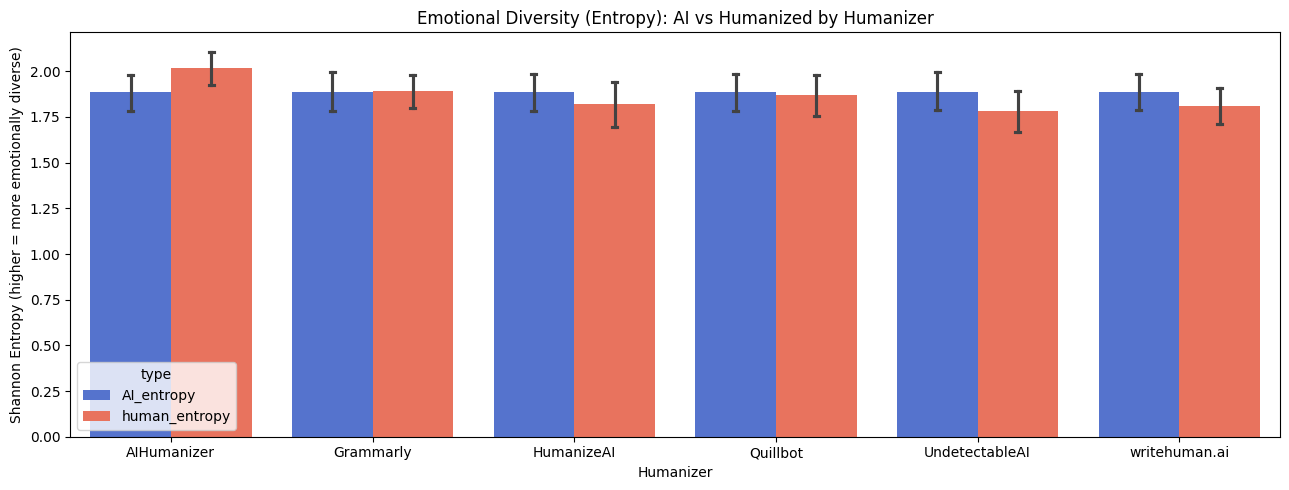

In [29]:
entropy_melt = df.melt(
    id_vars=["AI_model", "humanizer"],
    value_vars=["AI_entropy", "human_entropy"],
    var_name="type", value_name="entropy"
)

plt.figure(figsize=(13, 5))
sns.barplot(
    data=entropy_melt,
    x="humanizer", y="entropy",
    hue="type", palette=["royalblue", "tomato"],
    capsize=0.05
)
plt.title("Emotional Diversity (Entropy): AI vs Humanized by Humanizer")
plt.ylabel("Shannon Entropy (higher = more emotionally diverse)")
plt.xlabel("Humanizer")
plt.tight_layout()
plt.show()

In [30]:
from scipy.stats import wilcoxon

stat, p = wilcoxon(df["AI_entropy"].dropna(), df["human_entropy"].dropna())
print(f"Wilcoxon p-value: {p:.4f}")

Wilcoxon p-value: 0.0322


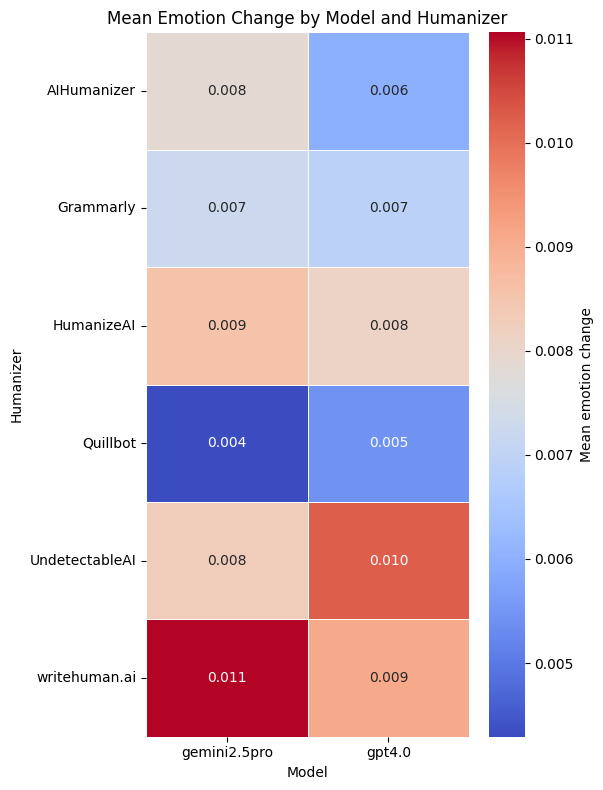

In [31]:
heatmap_pivot_T = heatmap_pivot.T  # flip rows and columns

plt.figure(figsize=(6, 8))  # taller than wide now
sns.heatmap(
    heatmap_pivot_T,
    annot=True,
    fmt=".3f",
    cmap="coolwarm",
    linewidths=0.5,
    cbar_kws={"label": "Mean emotion change"}
)
plt.title("Mean Emotion Change by Model and Humanizer")
plt.xlabel("Model")
plt.ylabel("Humanizer")
plt.tight_layout()
plt.show()